In [ ]:
"""
    鸢尾花数据集 iris 机器学习入门数据集
    三大分类：山鸢尾 杂色鸢尾 维吉尼亚鸢尾
    4个特征 花萼长度 花萼宽度 花瓣长度 花瓣宽度

    scikit-learn 加载鸢尾花数据集
    pandas 数据处理和保存csv文件
    matplotlib.pyplot 绘图库
    seaborn 高级统计绘图 绘制混淆矩阵热力图
"""

In [1]:
!uv pip show scikit-learn

Name: scikit-learn
Version: 1.9.0
Location: D:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv\Lib\site-packages
Requires: joblib, narwhals, numpy, scipy, threadpoolctl
Required-by:


Using Python 3.12.13 environment at: D:\Work\OldBack\Personal\Github Repository\ai_python_practice_questions\quetions\.venv


In [6]:
from sklearn.datasets import load_iris

iris_dataset = load_iris()
print("="*50)
print(f"{iris_dataset.keys()}")
print(f"数据集形状：{iris_dataset.data.shape}")
print(f"标签名称：{iris_dataset.target_names}")
print(f"标签形状：{iris_dataset.target.shape}")
print(f"数据集特征名称：{iris_dataset.feature_names}")
print("="*50)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
数据集形状：(150, 4)
标签名称：['setosa' 'versicolor' 'virginica']
标签形状：(150,)
数据集特征名称：['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [7]:
import pandas as pd
# 保存csv文件

df = pd.DataFrame(data=iris_dataset.data, columns=iris_dataset.feature_names)
df['species'] = iris_dataset.target_names[iris_dataset.target]
df.to_csv('iris_dataset_20260626.csv')

In [8]:
print(f"数据集形状：{df.shape}")
print("前10行数据：")
print(df.head(10))
print("统计信息：")
print(df.describe())
print("数据集各种类数量")
print(f"{df['species'].value_counts().sort_index()}")

数据集形状：(150, 5)
前10行数据：
   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  species
0                5.1               3.5  ...               0.2   setosa
1                4.9               3.0  ...               0.2   setosa
2                4.7               3.2  ...               0.2   setosa
3                4.6               3.1  ...               0.2   setosa
4                5.0               3.6  ...               0.2   setosa
5                5.4               3.9  ...               0.4   setosa
6                4.6               3.4  ...               0.3   setosa
7                5.0               3.4  ...               0.2   setosa
8                4.4               2.9  ...               0.2   setosa
9                4.9               3.1  ...               0.1   setosa

[10 rows x 5 columns]
统计信息：
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count         150.000000        150.000000         150.000000        150.000000
mean   

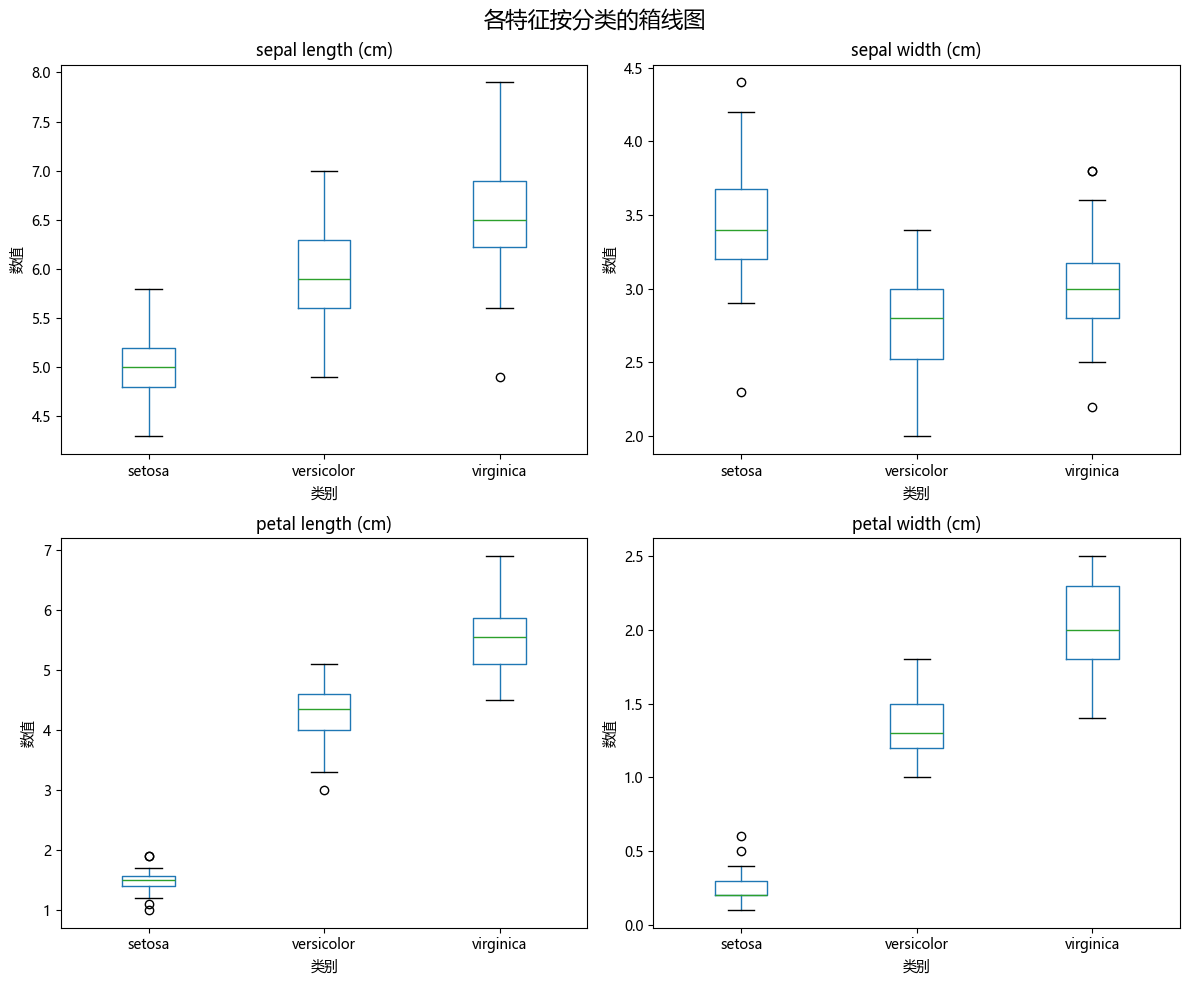

In [11]:
# 绘制箱线图 (按类别区分)
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, feature_name in enumerate(iris_dataset.feature_names):
    ax = axes[i // 2, i % 2]
    df.boxplot(column=feature_name, by='species', ax=ax, grid=False)
    ax.set_title(feature_name)
    ax.set_xlabel('类别')
    ax.set_ylabel('数值')
plt.suptitle('各特征按分类的箱线图', size=16)
plt.tight_layout()
plt.show()


In [12]:
# 鸢尾花数据集 训练集与测试集划分
from sklearn.model_selection import train_test_split

train_feature, test_feature, train_label, test_label = train_test_split(iris_dataset.data, iris_dataset.target, test_size=0.2, random_state=1)
print(f"训练集特征：{train_feature.shape}")
print(f"测试集特征：{test_feature.shape}")
print(f"训练集标签：{train_label.shape}")
print(f"测试集标签：{test_label.shape}")

训练集特征：(120, 4)
测试集特征：(30, 4)
训练集标签：(120,)
测试集标签：(30,)


In [ ]:
# 机器学习过程分三步 创建模型 -> 训练模型 -> 预测与评估

# 机器学习：从数据中学习规律，对新数据进行预测
# 监督学习：训练数据包含输入特征与已知的类别标签（带答案的学习）
# 分类任务：预测标本属于哪个离散的类型

# 机器学习领域 - 监督学习的分类算法
# 逻辑回归(LogisticRegression)：二分类(默认)，输出样本属于某一个类别的概率
# 支持向量机 SVM：分类(SVC), 回归(SVR)和异常检测，例如：直接判断这朵花属于 维吉尼亚鸢尾，并给出"决策边界"

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 引入 分层K折， 交叉验证
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn 

